# Chapter 6 — Completing the game: pairs, and a corner called surrender

Everything so far played a deliberately trimmed game: hit, stand, double. The real table offers two more decisions — **split** a pair into two hands, and **surrender** a hopeless one for half the bet back. This chapter turns both on and asks the question the whole report has been building toward: when the action space gets harder, does the smooth network's one weakness (Chapter 4's missing wall) stay one weakness, or multiply?

It multiplies — predictably. Splitting adds a *second* sharp-walled aggressive action, and the net over-uses it exactly the way it over-uses doubling. Surrender adds a rare defensive action, and the net never finds it at all. Both are the same failure from Chapter 4 — a smooth approximator cannot place a sharp boundary on a low-frequency action — now visible from two new directions.

The grid grows from 280 cells to 340: **+100 pair cells** (ten pair types × ten dealer upcards) and **+3 surrender cells**. And basic strategy's own edge *falls* — from ~0.12%/hand in the trimmed game to ~0.084% here — because every option you add is one more way to play a hand correctly.

> **On scope.** This chapter is a *complementary* check, not a full study. Splitting and surrender get nothing like the depth Chapters 2–5 gave to doubling — no encoding sweep, no curriculum, no per-cell autopsy, no multi-seed frontier. The single aim here is to confirm, at the level of the whole game, that Chapter 4's weakness generalises when the action space grows. Read the numbers below as a sanity check on the thesis, not as an analysis of optimal pair play.

## 6.1 — The exact table still nearly solves it

Before judging the network, fix the ceiling. A tabular Q-learner, storing every cell exactly, plays the pair game almost perfectly — its disagreements with basic are a handful of thin-margin cells, and its edge sits a whisker above optimal.

In [1]:
import sys; sys.path.insert(0, '.')
import json as _j
from pathlib import Path as _P
from collections import Counter
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from runs import load_runs, learning_curve, show, provenance, fignote, describe, OPTIMUM_PCT, EDGE_SE_PCT

df = load_runs()

# the complete game = splits AND surrender. Two matched DQN runs (seeds 42/43, 5M onehot).
COMPLETE = df[df.with_splits & df.with_surrender & (df.method == 'dqn') & (df.hidden == '[16, 16]')].sort_values('seed')
RUN  = COMPLETE.iloc[0]                                   # seed 42 — the worked example
# the exact-table ceiling: best tabular run on the pair game (NO tabular-with-surrender run exists)
TAB  = df[df.with_splits & (df.method == 'tabular')].sort_values('agreement').iloc[-1]

def back_half(row):
    lc = learning_curve(row.path)
    a = np.array([cp['agreement'] for cp in lc if 'agreement' in cp])
    return float(a[len(a)//2:].mean()) if len(a) else row.agreement

board = pd.DataFrame([
    dict(player='basic strategy (full optimum)', agreement=1.0, edge_pct=OPTIMUM_PCT['complete']),
    dict(player='tabular Q-learner (exact, pair game)', agreement=back_half(TAB), edge_pct=TAB.edge_pct),
    dict(player='DQN (smooth, complete game, seed 42)', agreement=back_half(RUN), edge_pct=RUN.edge_pct),
])
show(board, pct=['agreement'], num=['edge_pct'],
     caption='Exact methods nearly solve it, the smooth net does not (tabular ceiling = pair game; no surrender-enabled tabular run exists). Optimum = full basic ≈ 0.54% (lit.; in-harness 0.58%±0.10 over 1.4M); each learner edge is one 200k seed-0 eval, ±0.26%/hand.',
     source='source: agreement = back-half mean vs basic; edge = %/hand vs the same fresh-shoe hands. '
            'tabular = pair game (splits, surrender off); DQN = complete game — ' + describe(RUN, seed=False))

player,agreement,edge_pct
basic strategy (full optimum),100.0%,0.54
"tabular Q-learner (exact, pair game)",94.0%,0.17
"DQN (smooth, complete game, seed 42)",83.0%,1.03


**Reading it.** The tabular learner reaches ~0.94 agreement and an edge statistically at optimal (its 0.17% sample sits within the ±0.26% band of the ~0.54% optimum) — the game is *learnable to near-perfection* if you can store each cell on its own. The DQN, sharing one smooth function across all of them, sits ~10 points lower in agreement and pays a few tenths of a percent above optimal on edge (~0.95% vs ~0.54%, ≈1.5 SE). That gap — small in the trimmed game, wide here — is the rest of this chapter.

*One honesty note on this comparison.* No tabular run in our set has surrender enabled, so the exact ceiling is measured on the **pair game** (splits, 367 cells, surrender off). Since basic surrenders in only 3 of 340 cells, this is a faithful stand-in for the complete game — the tabular score would barely move with surrender on — but the ceiling is, strictly, the pair-game ceiling, and the DQN it is compared against also misses those 3 surrender cells (§6.3).

## 6.2 — The second wall: over-splitting

Split is an aggressive action with a sharp, low-frequency boundary: split these few pairs against these few dealer cards, hit otherwise. It is the doubling problem again, on a new axis — and the network fails it the same way. It splits **72 cells where basic splits 52**, and the extra splitting is overwhelmingly one-directional: pairs it should simply *hit*, split anyway. There are a couple of *under*-splits too (one or two per run — a pair basic splits that the agent stands or doubles), but they are dwarfed by the over-splits, as the breakdown shows.

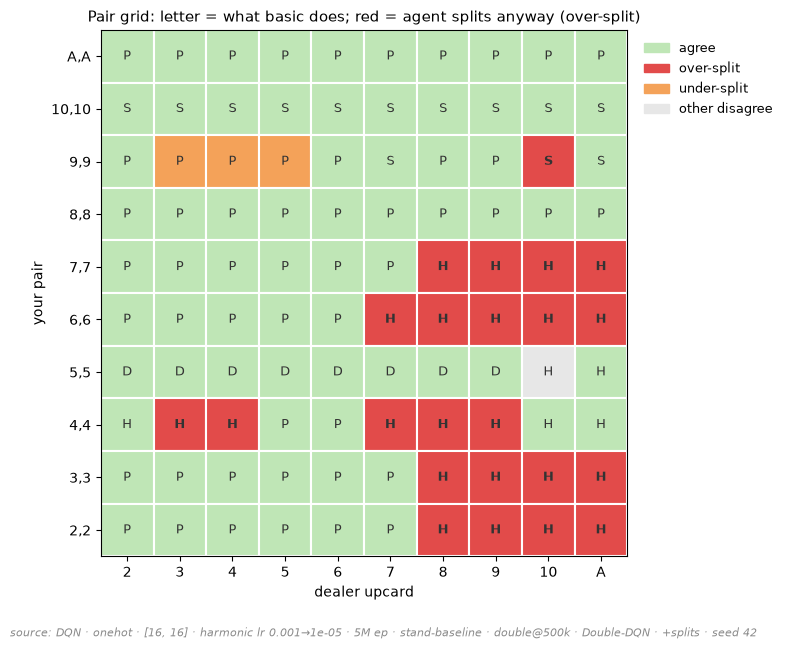

run,genuine,over_split,under_split,over_double,missed_surrender
"[16, 16] splits only, 1.5M, seed 42",63,22,5,32,0
"[16, 16] splits only, 5M, seed 42",50,24,2,17,0
"[16, 16] splits only, 10M, seed 42",46,22,0,19,0
"[16, 16] splits+surrender, 5M, seed 42",54,23,2,17,3
"[64, 64] splits+surrender, 5M, seed 42",50,24,1,15,3
"[16, 16] splits+surrender, 5M, seed 43",56,21,2,22,3


In [2]:
def scat(c):
    a, b = c['agent_action'], c['basic_action']
    if a == b:                        return 0   # correct
    if a == 'split' and b != 'split': return 1   # OVER-split
    if b == 'split' and a != 'split': return 2   # under-split
    return 3                                     # other disagreement
SCOL = ['#bfe6b6', '#e24b4a', '#f4a259', '#e7e7e7']
ACT  = {'hit':'H','stand':'S','double':'D','split':'P','surrender':'R'}
PAIR = {(4,False):'2,2',(6,False):'3,3',(8,False):'4,4',(10,False):'5,5',(12,False):'6,6',
        (14,False):'7,7',(16,False):'8,8',(18,False):'9,9',(20,False):'10,10',(12,True):'A,A'}
ROWS = ['A,A','10,10','9,9','8,8','7,7','6,6','5,5','4,4','3,3','2,2']
COLS = list(range(2,12))

cells = _j.load(open(_P(RUN.path)/'record.json', encoding='utf-8'))['diff']['cells']
pairs = {(PAIR.get((c['player_value'], c['is_soft'])), c['dealer_upcard']): c
         for c in cells if c.get('can_split') and (c['player_value'], c['is_soft']) in PAIR}

fig, ax = plt.subplots(figsize=(7.2, 6.2))
for i, rlab in enumerate(ROWS):
    for j, d in enumerate(COLS):
        c = pairs.get((rlab, d))
        if c is None:
            ax.add_patch(plt.Rectangle((j,i),1,1,facecolor='white',edgecolor='#dddddd')); continue
        cat = scat(c)
        ax.add_patch(plt.Rectangle((j,i),1,1,facecolor=SCOL[cat],edgecolor='white',lw=1.5))
        ax.text(j+0.5, i+0.5, ACT[c['basic_action']], ha='center', va='center',
                fontsize=9, color='#333', fontweight='bold' if cat==1 else 'normal')
ax.set_xlim(0,len(COLS)); ax.set_ylim(0,len(ROWS)); ax.set_aspect('equal'); ax.invert_yaxis()
ax.set_xticks([j+0.5 for j in range(len(COLS))]); ax.set_xticklabels(['A' if d==11 else d for d in COLS])
ax.set_yticks([i+0.5 for i in range(len(ROWS))]); ax.set_yticklabels(ROWS)
ax.set_xlabel('dealer upcard'); ax.set_ylabel('your pair')
ax.set_title('Pair grid: letter = what basic does; red = agent splits anyway (over-split)', fontsize=11)
leg = [mpatches.Patch(color=SCOL[0],label='agree'), mpatches.Patch(color=SCOL[1],label='over-split'),
       mpatches.Patch(color=SCOL[2],label='under-split'), mpatches.Patch(color=SCOL[3],label='other disagree')]
ax.legend(handles=leg, loc='upper left', bbox_to_anchor=(1.01,1), frameon=False, fontsize=9)
fignote('source: ' + describe(RUN))
plt.tight_layout(); plt.show()

def breakdown(row):
    d = [c for c in _j.load(open(_P(row.path)/'record.json',encoding='utf-8'))['diff']['cells']
         if c['category']=='genuine_disagreement']
    osp = sum(1 for c in d if c['agent_action']=='split'  and c['basic_action']!='split')
    usp = sum(1 for c in d if c['basic_action']=='split'  and c['agent_action']!='split')
    odl = sum(1 for c in d if c['agent_action']=='double' and c['basic_action']!='double')
    sur = sum(1 for c in d if c['basic_action']=='surrender')
    cfg = ('splits+surrender' if row.with_surrender else 'splits only')
    return dict(run='%s %s, %gM, seed %s'%(row.hidden,cfg,row.episodes/1e6,row.seed), genuine=len(d),
                over_split=osp, under_split=usp, over_double=odl, missed_surrender=sur)

splits_runs = df[df.with_splits & (df.method=='dqn')].sort_values(['with_surrender','episodes','seed'])
tab2 = pd.DataFrame([breakdown(r) for _,r in splits_runs.iterrows()])
show(tab2, caption='Over-aggression is the dominant error, and it is consistent across seeds and length',
     source='source: genuine-disagreement cells per run; over-split = agent splits where basic does not; '
            'missed_surrender = basic surrenders, agent does not. all onehot [16,16] harmonic Double-DQN, seed 42/43')

**Reading it.** The red cells cluster exactly where you'd predict: low pairs (2,2 · 3,3 · 4,4 · 6,6 · 7,7) against *strong* dealer upcards (8, 9, 10, A) — the region where basic says "this pair is garbage, just hit." Basic splits only against dealer weakness; the rule "split here, not there" is a sharp wall, and the smooth net rounds straight over it, spilling splits into the strong-dealer half of the grid. It even splits 9,9 against a 10 and an Ace, where basic stands.

This is Chapter 4's mechanism verbatim, transplanted onto a new action. There the net over-doubled one cell past the double region's edge; here it over-splits a whole ring past the split region's edge. The breakdown table makes it robust: across all four runs, over-splits (20–24) and over-doubles (17–32) together account for most of every run's genuine disagreements, while under-splits never exceed five and usually sit at two. (On the full game `over_double` also picks up a single *pair* cell — a 4,4 doubled instead of split — out of 15–17, so it is all but entirely genuine non-pair over-doubling.) The network's bias is not random error — it is a systematic over-extension of every aggressive action whose correct region has a hard edge.

## 6.3 — The corner it never enters: surrender

Surrender is the opposite kind of action: defensive, and rare. In this rule set basic strategy surrenders in just **three** of the 340 cells — hard 15 vs 10, hard 16 vs 9, and hard 16 vs 10 — the three hands so bad that giving up half your bet beats playing on. The network surrenders in **zero**. It hits all three.

In [3]:
sur = [c for c in cells if c['basic_action']=='surrender']
srow = pd.DataFrame([dict(hand='hard %d'%c['player_value'], dealer=('A' if c['dealer_upcard']==11 else c['dealer_upcard']),
                          basic=c['basic_action'], agent=c['agent_action']) for c in sur])
show(srow, caption='The three surrender cells — basic gives up, the agent hits every one',
     source='source: ' + describe(RUN) + ' · surrender enabled (with_surrender=True)')

hand,dealer,basic,agent
hard 15,10,surrender,hit
hard 16,9,surrender,hit
hard 16,10,surrender,hit


**Reading it.** Surrender fails for the same reason over-splitting succeeds-too-often: a smooth function cannot carve out a sharp, low-frequency island. Splitting's correct region has a hard *outer* edge, so the net overshoots it. Surrender's correct region is three isolated cells with a thin EV margin over hitting — so the net, averaging over their common neighbours, never lifts surrender's value above hit's anywhere, and the island simply never forms. One action gets over-used, the other never used; both are the absence of a wall.

The cost is small — three rare cells — so it barely moves the edge, and we don't dress it up as more than it is. But it completes the picture: the smooth approximator's single structural weakness shows up as *over-aggression* on sharp-bounded aggressive actions and as *blindness* to rare defensive ones.

## 6.4 — Training length, and the ceiling it never reaches

Does more training rescue the full game? It helps, on the same terms as Chapter 5: the over-aggression shrinks and the edge falls, but it plateaus short of the exact-table ceiling. On the splits game the edge runs 2.05% → 1.12% → 0.74% across 1.5M, 5M and 10M episodes, and back-half agreement climbs 0.82 → 0.84 → 0.85 — real improvement, never closing on tabular's 0.94.

episodes,back_half_agreement,edge_pct
1.5M,81.9%,2.05
5M,84.0%,1.12
10M,84.7%,0.74


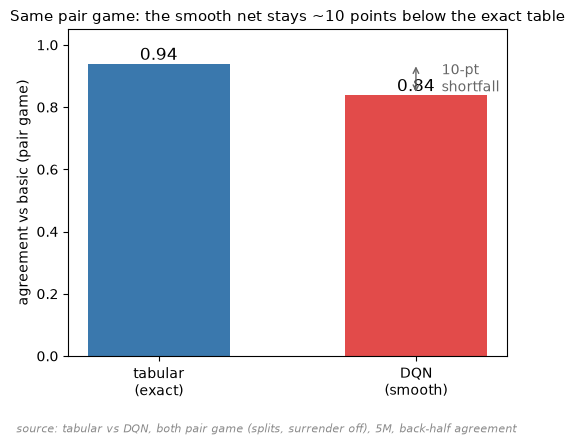

network,back_half_agreement,edge_pct,over_split
"[16, 16]",83.0%,1.03,23
"[64, 64]",84.1%,0.92,24


In [4]:
length = df[df.with_splits & (df.method=='dqn') & ~df.with_surrender].sort_values('episodes')
ltab = pd.DataFrame([dict(episodes='%gM'%(r.episodes/1e6), back_half_agreement=back_half(r), edge_pct=r.edge_pct)
                     for _, r in length.iterrows()])
show(ltab, pct=['back_half_agreement'], num=['edge_pct'],
     caption='More training shrinks the over-aggression but plateaus short of the exact-table ceiling',
     source='source: splits-only series (surrender off), onehot [16,16] harmonic Double-DQN, seed 42 · '
            'back-half mean agreement, edge %/hand vs basic')

# the exact-vs-approximate ceiling on the SAME game (pair game, both methods) — just two bars
DQN_PAIR = df[df.with_splits & ~df.with_surrender & (df.method=='dqn') & (df.episodes==5_000_000)].iloc[0]
tab_ag, dqn_ag = back_half(TAB), back_half(DQN_PAIR)   # both pair game, 5M, surrender off
fig, ax = plt.subplots(figsize=(5.2, 4.2))
bars = ax.bar(['tabular\n(exact)', 'DQN\n(smooth)'], [tab_ag, dqn_ag], width=0.55, color=['#3a78ad', '#e24b4a'])
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.012, '%.2f'%b.get_height(), ha='center', fontsize=12)
ax.annotate('', xy=(1, dqn_ag), xytext=(1, tab_ag), arrowprops=dict(arrowstyle='<->', color='#666'))
ax.text(1.10, (tab_ag+dqn_ag)/2, '%.0f-pt\nshortfall'%((tab_ag-dqn_ag)*100), color='#666', fontsize=10, va='center')
ax.set_ylim(0, 1.05); ax.set_ylabel('agreement vs basic (pair game)')
ax.set_title('Same pair game: the smooth net stays ~%.0f points below the exact table'%((tab_ag-dqn_ag)*100), fontsize=10.5)
fignote('source: tabular vs DQN, both pair game (splits, surrender off), 5M, back-half agreement')
plt.tight_layout(); plt.show()

# does more CAPACITY help the full game? the matched [64,64] complete-game run vs the [16,16] hero
def cap_row(row):
    d = [c for c in _j.load(open(_P(row.path)/'record.json',encoding='utf-8'))['diff']['cells']
         if c['category']=='genuine_disagreement']
    osp = sum(1 for c in d if c['agent_action']=='split' and c['basic_action']!='split')
    return dict(network=row.hidden, back_half_agreement=back_half(row), edge_pct=row.edge_pct, over_split=osp)
cap = df[df.with_splits & df.with_surrender & (df.method=='dqn') & (df.seed==42)].sort_values('hidden')
captab = pd.DataFrame([cap_row(r) for _, r in cap.iterrows()])
show(captab, pct=['back_half_agreement'], num=['edge_pct'],
     caption='Four times the neurons, same wall: capacity barely moves agreement or the over-splitting',
     source='source: complete game (splits+surrender), harmonic Double-DQN, 5M, seed 42 — [16,16] vs [64,64]')

**Reading it — length, and capacity.** Two levers, neither closes the gap. *Length:* on the pair game the smooth net plateaus about ten points below the exact table, and more training never erases it. *Capacity:* four times the neurons ([16,16] → [64,64], complete game) moves back-half agreement by about a point — 0.830 → 0.841, well inside the seed band — and leaves the over-splitting untouched (24 over-splits either way). Edge shifts within noise (1.03% vs 0.92% — a 0.11% gap inside the ±0.26% eval band), so we don't read a real edge gain into it; the over-splitting is unchanged either way.

That [64,64] run also settles the cross-game question cleanly, with the network held fixed. The same architecture scores 0.911 on the trimmed game and 0.841 on the complete game; against the exact table (0.928 → 0.940) the agreement gap widens from **~2 points to ~10**. Because the net is identical across the two games, that widening is real — not the [16,16]-vs-[64,64] artifact we were careful not to claim earlier. Adding hard-edged actions, not shrinking the network, is what opens the gap. Capacity was never the missing wall; representation is.

## 6.5 — Verdict

The complete game confirms the thesis the whole report has been assembling, and sharpens it. The smooth network's weakness is not about doubling, or about any one action. It is structural: **a single smooth function cannot represent the sharp, low-frequency boundaries that optimal blackjack is made of.** Give it an aggressive action with a hard edge — double, split — and it over-extends past the edge. Give it a rare defensive action — surrender — and it never carves out the island. An exact table, free to memorise each cell, does all of it nearly perfectly.

So the headline holds at full size: this DQN plays a competent, recognisably-good complete game — roughly 1% to the house — but it is competent *despite* a fixed structural ceiling, not on its way to closing it. The ceiling is the price of generalisation, and it is exactly the wall Chapter 4 found, now counted twice over.

And to be clear about what this chapter is and is not: it is a confirmation, not an investigation. We did not tune, sweep, or dissect splitting and surrender the way we dissected doubling — they are here to show the full game behaves as the trimmed game predicted, and no more should be read into the pair-play numbers than that.